<a href="https://colab.research.google.com/github/preethi-raddi/Zomato-data-analysis/blob/main/DataAnalysis_MiniPorject1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

This project aims to analyse zomato's data using basic graphic representations.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data_zomato = pd.read_csv('/content/Zomato_dataset.csv')
print(data_zomato.head(7))

                                              name online_order book_table  \
0                                            Jalsa          Yes        Yes   
1                                   Spice Elephant          Yes         No   
2                                  San Churro Cafe          Yes         No   
3                            Addhuri Udupi Bhojana           No         No   
4                                    Grand Village           No         No   
5                                  Timepass Dinner          Yes         No   
6  Rosewood International Hotel - Bar & Restaurant           No         No   

    rate  votes  approx_cost(for two people) listed_in(type)  
0  4.1/5    775                          800          Buffet  
1  4.1/5    787                          800          Buffet  
2  3.8/5    918                          800          Buffet  
3  3.7/5     88                          300          Buffet  
4  3.8/5    166                          600          Buffet

In [3]:
data_zomato.describe()

,votes,approx_cost(for two people)
count,148.000000,148.000000
mean,264.810811,418.243243
std,653.676951,223.085098
min,0.000000,100.000000
25%,6.750000,200.000000
50%,43.500000,400.000000
75%,221.750000,600.000000
max,4884.000000,950.000000


In [4]:
data_zomato.count() # to check the total number of rows seperately

,0
name,148
online_order,148
book_table,148
rate,148
votes,148
approx_cost(for two people),148
listed_in(type),148


In [5]:
data_zomato.info() #

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148 entries, 0 to 147
Data columns (total 7 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   name                         148 non-null    object
 1   online_order                 148 non-null    object
 2   book_table                   148 non-null    object
 3   rate                         148 non-null    object
 4   votes                        148 non-null    int64 
 5   approx_cost(for two people)  148 non-null    int64 
 6   listed_in(type)              148 non-null    object
dtypes: int64(2), object(5)
memory usage: 8.2+ KB


In [6]:
data_zomato.isna().sum() # to cehck if there are any null objects

,0
name,0
online_order,0
book_table,0
rate,0
votes,0
approx_cost(for two people),0
listed_in(type),0


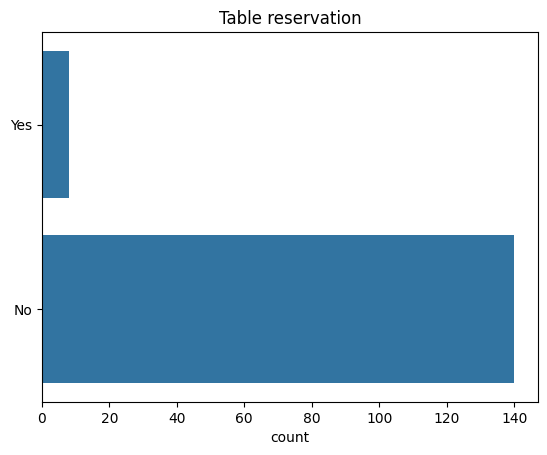

In [7]:
sns.countplot(data_zomato['book_table'])
plt.title('Table reservation')
plt.ylabel('')
plt.show()

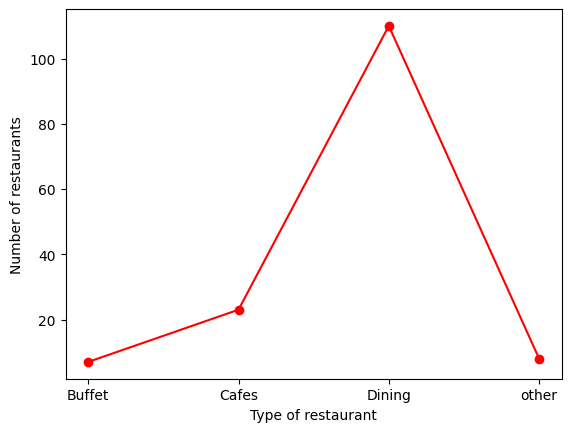

In [11]:
grouped_plot = data_zomato.groupby('listed_in(type)')['name'].count()
result = pd.DataFrame({'name':grouped_plot})
plt.plot(result,marker='o',color='red')
plt.xlabel('Type of restaurant')
plt.ylabel('Number of restaurants')
plt.show()

In [13]:
max_votes=data_zomato['votes'].max()
restraunt_max_votes=data_zomato[data_zomato['votes']==max_votes]
print(restraunt_max_votes)

                 name online_order book_table   rate  votes  \
38  Empire Restaurant          Yes         No  4.4/5   4884   

    approx_cost(for two people) listed_in(type)  
38                          750           other  


In [14]:
def handlerate(rate):
  if(type(rate)==str):
    rate=rate.split('/')
    rate=rate[0]
  return float(rate)
data_zomato['rate']=data_zomato['rate'].apply(handlerate)
data_zomato

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1,775,800,Buffet
1,Spice Elephant,Yes,No,4.1,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7,88,300,Buffet
4,Grand Village,No,No,3.8,166,600,Buffet
...,...,...,...,...,...,...,...
143,Melting Melodies,No,No,3.3,0,100,Dining
144,New Indraprasta,No,No,3.3,0,150,Dining
145,Anna Kuteera,Yes,No,4.0,771,450,Dining
146,Darbar,No,No,3.0,98,800,Dining


Text(0, 0.5, 'No of restraunts')

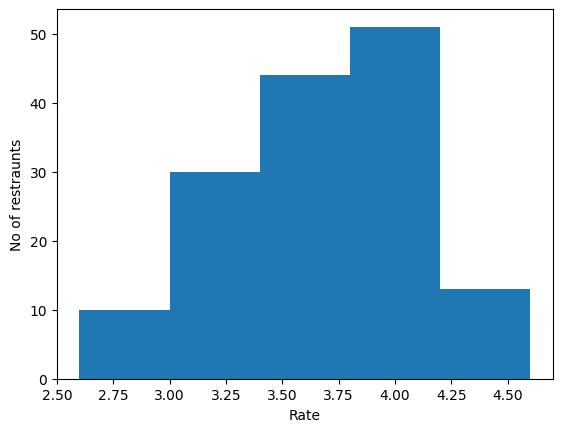

In [18]:
plt.hist(data_zomato['rate'],bins=5)
plt.xlabel('Rate')
plt.ylabel('No of restraunts')

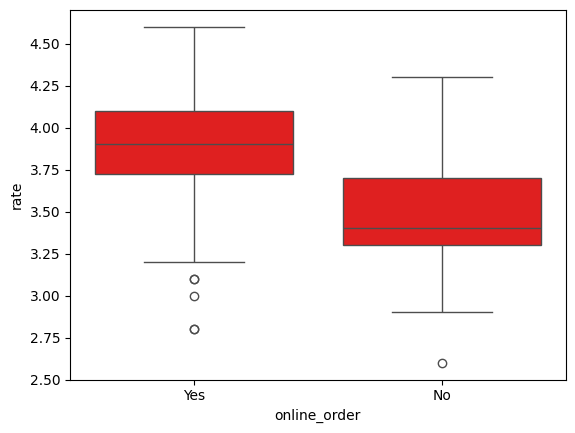

In [25]:
sns.boxplot(x=data_zomato['online_order'], y=data_zomato['rate'],color="red")
plt.show()

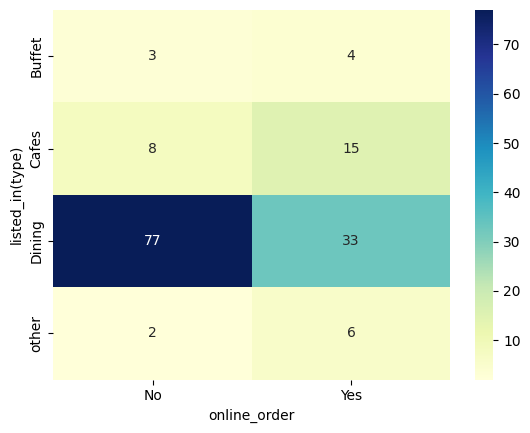

In [27]:
pivot_table=data_zomato.pivot_table(index=data_zomato['listed_in(type)'], columns=data_zomato['online_order'], aggfunc='size')
sns.heatmap(pivot_table, annot=True, fmt='d', cmap='YlGnBu')
plt.show()